/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


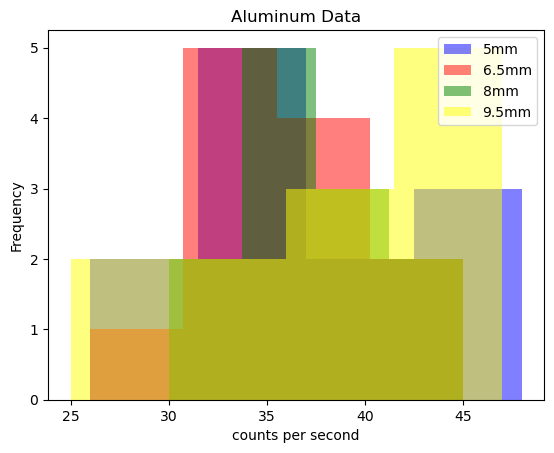

5mm Mean: 36.08, Std Dev: 6.53
6.5mm Mean: 36.67, Std Dev: 5.03
8mm Mean: 37.33, Std Dev: 4.33
9.5mm Mean: 37.67, Std Dev: 7.02


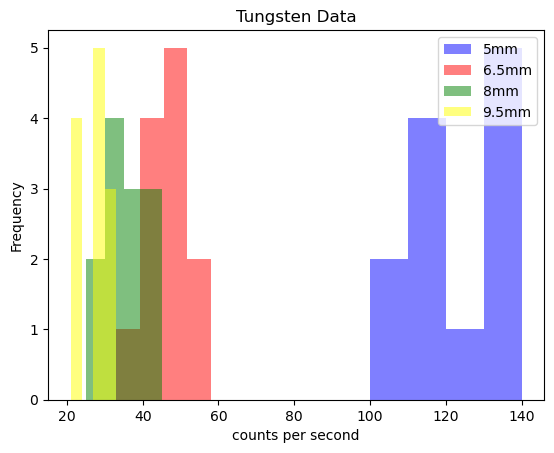

5mm Mean: 121.75, Std Dev: 6.53
6.5mm Mean: 45.50, Std Dev: 5.03
8mm Mean: 35.00, Std Dev: 4.33
9.5mm Mean: 27.00, Std Dev: 7.02


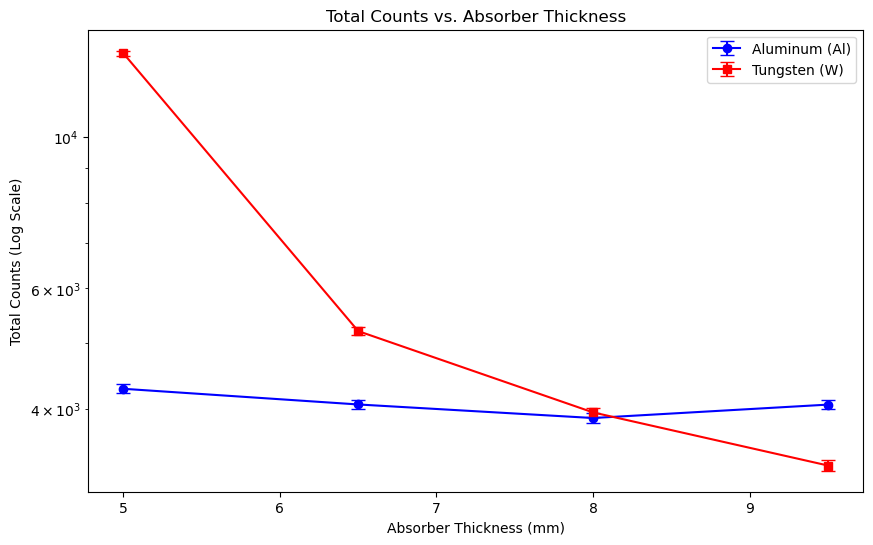

Aluminum μ: 0.0118 mm^-1
Tungsten μ: 0.3082 mm^-1


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rad_data = pd.read_csv('data/Radiation_Data2.csv')

rad_data_split = np.array_split(rad_data, 9)
first = rad_data_split[1]
second = rad_data_split[2]
third = rad_data_split[3]
fourth = rad_data_split[4]
fifth = rad_data_split[5]
sixth = rad_data_split[6]
seventh = rad_data_split[7]
eighth = rad_data_split[8]

plt.hist(first['cps'], bins = 4, label = '5mm', color='blue', alpha = 0.5)
plt.hist(second['cps'], bins = 4, label = '6.5mm', color='red', alpha = 0.5)
plt.hist(third['cps'], bins = 4, label = '8mm', color='green', alpha = 0.5)
plt.hist(fourth['cps'], bins = 4, label = '9.5mm', color='yellow', alpha = 0.5)
plt.ylabel('Frequency')
plt.xlabel('counts per second')
plt.title('Aluminum Data')
plt.legend(loc = 'upper right')
plt.show()

mean_1 = first['cps'].mean()
mean_2 = second['cps'].mean()
mean_3 = third['cps'].mean()
mean_4 = fourth['cps'].mean()

std_1 = first['cps'].std()
std_2 = second['cps'].std()
std_3 = third['cps'].std()
std_4 = fourth['cps'].std()

print(f"5mm Mean: {mean_1:.2f}, Std Dev: {std_1:.2f}")
print(f"6.5mm Mean: {mean_2:.2f}, Std Dev: {std_2:.2f}")
print(f"8mm Mean: {mean_3:.2f}, Std Dev: {std_3:.2f}")
print(f"9.5mm Mean: {mean_4:.2f}, Std Dev: {std_4:.2f}")

plt.hist(fifth['cps'], bins = 4, label = '5mm', color='blue', alpha = 0.5)
plt.hist(sixth['cps'], bins = 4, label = '6.5mm', color='red', alpha = 0.5)
plt.hist(seventh['cps'], bins = 4, label = '8mm', color='green', alpha = 0.5)
plt.hist(eighth['cps'], bins = 4, label = '9.5mm', color='yellow', alpha = 0.5)
plt.ylabel('Frequency')
plt.xlabel('counts per second')
plt.title('Tungsten Data')
plt.legend(loc = 'upper right')
plt.show()

mean_5 = fifth['cps'].mean()
mean_6 = sixth['cps'].mean()
mean_7 = seventh['cps'].mean()
mean_8 = eighth['cps'].mean()

std_5 = first['cps'].std()
std_6 = second['cps'].std()
std_7 = third['cps'].std()
std_8 = fourth['cps'].std()

print(f"5mm Mean: {mean_5:.2f}, Std Dev: {std_1:.2f}")
print(f"6.5mm Mean: {mean_6:.2f}, Std Dev: {std_2:.2f}")
print(f"8mm Mean: {mean_7:.2f}, Std Dev: {std_3:.2f}")
print(f"9.5mm Mean: {mean_8:.2f}, Std Dev: {std_4:.2f}")

thicknesses = [5, 6.5, 8, 9.5]

def get_total_counts(df):
    return df['total_count'].iloc[-1] - df['total_count'].iloc[0]

counts_Al = [
    get_total_counts(first),
    get_total_counts(second),
    get_total_counts(third),
    get_total_counts(fourth)
]

error_Al = np.sqrt(counts_Al)

counts_W = [
    get_total_counts(fifth),
    get_total_counts(sixth),
    get_total_counts(seventh),
    get_total_counts(eighth)
]

error_W = np.sqrt(counts_W)

plt.figure(figsize=(10, 6))

plt.errorbar(thicknesses, counts_Al, yerr=error_Al, fmt='o-', capsize=5, label='Aluminum (Al)', color='blue')

plt.errorbar(thicknesses, counts_W, yerr=error_W, fmt='s-', capsize=5, label='Tungsten (W)', color='red')

plt.yscale('log')
plt.xlabel('Absorber Thickness (mm)')
plt.ylabel('Total Counts (Log Scale)')
plt.title('Total Counts vs. Absorber Thickness')
plt.legend()
plt.show()

thick_diff = thicknesses[3] - thicknesses[0]

mu_Al_2pt = (np.log(counts_Al[0]) - np.log(counts_Al[3])) / thick_diff
mu_W_2pt = (np.log(counts_W[0]) - np.log(counts_W[3])) / thick_diff

print(f"Aluminum μ: {mu_Al_2pt:.4f} mm^-1")
print(f"Tungsten μ: {mu_W_2pt:.4f} mm^-1")

the measured std is higher than we would expect from normal counting statistics and we should see that the counts measured as the thickness of blocking material increases, but we do not see that. 

the tungsten has a much higher absorption coeff because it is denser and has more elements for radiation to run into.